# NSL-KDD Intrusion Detection

In [1]:
import pandas as pd
import numpy as np
from collections import Counter

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, pairwise_distances_argmin
from sklearn.metrics import pairwise_distances_argmin_min

from imblearn.over_sampling import BorderlineSMOTE
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
import shap
import warnings
warnings.filterwarnings('ignore')

## 1. Load Data

In [2]:
train = pd.read_csv("kdd_train.csv", header=None)
test = pd.read_csv("kdd_test.csv", header=None)

columns = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
    "wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root",
    "num_file_creations","num_shells","num_access_files","num_outbound_cmds",
    "is_host_login","is_guest_login","count","srv_count","serror_rate",
    "srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate",
    "diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate",
    "dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate",
    "label"
]

train.columns = columns
test.columns = columns

train = train.iloc[1:].copy()
test = test.iloc[1:].copy()

## 2. Label Mapping & Filtering

In [3]:
common_labels = set(train['label']) & set(test['label'])
train = train[train['label'].isin(common_labels)]
test = test[test['label'].isin(common_labels)]

def map_attack(label):
    if label == 'normal':
        return 'normal'
    elif label in ['back','land','neptune','pod','smurf','teardrop',
                   'apache2','udpstorm','processtable','worm']:
        return 'dos'
    elif label in ['ipsweep','nmap','portsweep','satan','mscan','saint']:
        return 'probe'
    elif label in ['ftp_write','guess_passwd','imap','multihop','phf','spy',
                   'warezclient','warezmaster','sendmail','named',
                   'snmpgetattack','snmpguess','xlock','xsnoop','httptunnel']:
        return 'r2l'
    elif label in ['buffer_overflow','loadmodule','perl','rootkit',
                   'ps','sqlattack','xterm']:
        return 'u2r'
    else:
        return 'unknown'

train['label'] = train['label'].apply(map_attack)
test['label'] = test['label'].apply(map_attack)

X_train = train.drop(columns=["label"])
y_train = train["label"]
X_test = test.drop(columns=["label"])
y_test = test["label"]

print("Train distribution:", Counter(y_train))
print("Test distribution:", Counter(y_test))

Train distribution: Counter({'normal': 67343, 'dos': 45927, 'probe': 11656, 'r2l': 993, 'u2r': 52})
Test distribution: Counter({'normal': 11245, 'dos': 7562, 'probe': 1754, 'r2l': 811, 'u2r': 26})


## 3. Preprocessing
### FIX: LabelEncoder disimpan per kolom dalam dict agar tidak tertimpa

In [4]:
categorical_cols = ["protocol_type", "service", "flag"]

# FIX: simpan setiap encoder dalam dict, bukan variabel tunggal yang ditimpa
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    # Handle unseen categories di test set
    X_test[col] = X_test[col].apply(
        lambda x: x if x in le.classes_ else le.classes_[0]
    )
    X_test[col] = le.transform(X_test[col])
    label_encoders[col] = le  # simpan encoder per kolom

print("Categorical encoding done. Encoders saved:", list(label_encoders.keys()))

Categorical encoding done. Encoders saved: ['protocol_type', 'service', 'flag']


## 4. Target Label Encoder & Scaling (Full Features)

In [5]:
# Label encoder untuk target - fit hanya dari y_train
label_encoder = LabelEncoder()
label_encoder.fit(y_train)

y_train_encoded = label_encoder.transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Scaling - fit hanya dari X_train
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Classes:", label_encoder.classes_)
print("X_train_scaled shape:", X_train_scaled.shape)

Classes: ['dos' 'normal' 'probe' 'r2l' 'u2r']
X_train_scaled shape: (125971, 41)


## 5. Baseline: XGBoost tanpa Sampling (Unbalanced)

In [6]:
print("Training baseline XGBoost (unbalanced)...")

model_xgb_unbalanced = XGBClassifier(
    n_estimators=300, max_depth=8, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='mlogloss', random_state=42, n_jobs=-1
)
model_xgb_unbalanced.fit(X_train_scaled, y_train_encoded)
y_pred_unbalanced = model_xgb_unbalanced.predict(X_test_scaled)

print("\n=== Baseline (Unbalanced) ===")
print(classification_report(y_test_encoded, y_pred_unbalanced,
                             target_names=label_encoder.classes_))

Training baseline XGBoost (unbalanced)...

=== Baseline (Unbalanced) ===
              precision    recall  f1-score   support

         dos       1.00      1.00      1.00      7562
      normal       0.94      0.99      0.97     11245
       probe       0.96      1.00      0.98      1754
         r2l       1.00      0.20      0.33       811
         u2r       1.00      0.46      0.63        26

    accuracy                           0.96     21398
   macro avg       0.98      0.73      0.78     21398
weighted avg       0.97      0.96      0.95     21398



## 6. Hybrid Sampling: KMeans Undersampling + BorderlineSMOTE

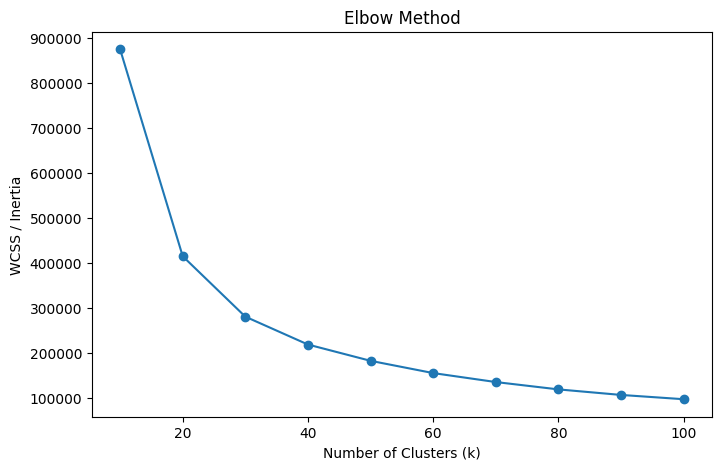

In [7]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia_values = []

k_range = range(10, 101, 10)

X_normal = X_train_scaled[y_train == 'normal']

for k in k_range:

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    km.fit(X_normal)

    inertia_values.append(km.inertia_)

plt.figure(figsize=(8,5))

plt.plot(k_range, inertia_values, marker='o')

plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS / Inertia")
plt.title("Elbow Method")

plt.show()

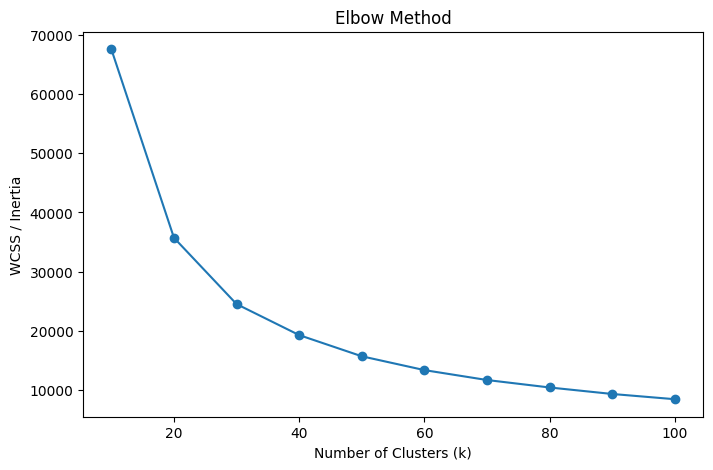

In [8]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia_values = []

k_range = range(10, 101, 10)

X_normal = X_train_scaled[y_train == 'dos']

for k in k_range:

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    km.fit(X_normal)

    inertia_values.append(km.inertia_)

plt.figure(figsize=(8,5))

plt.plot(k_range, inertia_values, marker='o')

plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS / Inertia")
plt.title("Elbow Method")

plt.show()

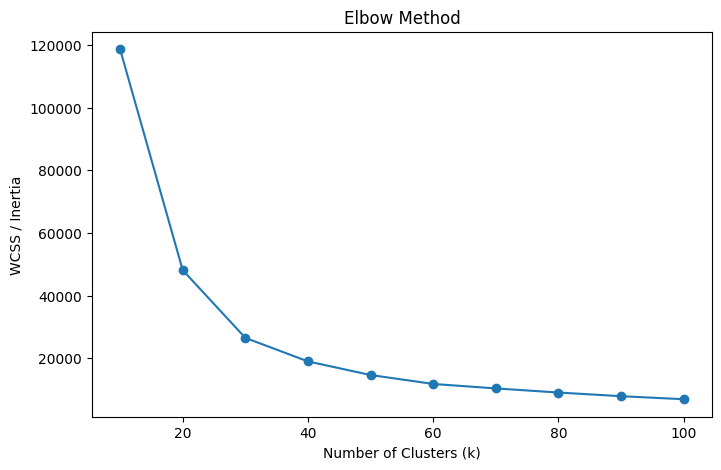

In [9]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia_values = []

k_range = range(10, 101, 10)

X_normal = X_train_scaled[y_train == 'probe']

for k in k_range:

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    km.fit(X_normal)

    inertia_values.append(km.inertia_)

plt.figure(figsize=(8,5))

plt.plot(k_range, inertia_values, marker='o')

plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS / Inertia")
plt.title("Elbow Method")

plt.show()

In [10]:
def kmeans_undersample(
    X,
    y,
    sampling_strategy,
    cluster_strategy,
    random_state=42
):
    """
    KMeans Cluster-Based Undersampling
    - Majority class dibagi menjadi sejumlah cluster
    - Sampling dilakukan secara proporsional dari setiap cluster
    """

    X_result, y_result = [], []
    unique_classes = np.unique(y)
    rng = np.random.RandomState(random_state)

    for cls in unique_classes:

        mask = (y == cls) if not hasattr(y, 'values') else (y.values == cls)
        X_cls = X[mask]

        target_n = sampling_strategy.get(cls, len(X_cls))
        n_cluster_cls = cluster_strategy.get(cls, 40)

        # -------------------------------
        # Minority class
        # -------------------------------
        if len(X_cls) <= target_n:

            X_result.append(X_cls)
            y_result.extend([cls] * len(X_cls))

        # -------------------------------
        # Majority class
        # -------------------------------
        else:

            print(f"\nClass : {cls}")
            print(f"Original samples : {len(X_cls)}")
            print(f"Target samples   : {target_n}")
            print(f"Clusters used    : {n_cluster_cls}")

            km = KMeans(
                n_clusters=n_cluster_cls,
                random_state=random_state,
                n_init=10,
                max_iter=300
            )

            cluster_labels = km.fit_predict(X_cls)

            samples_per_cluster = target_n // n_cluster_cls

            selected_indices = []

            for cluster_id in range(n_cluster_cls):

                cluster_idx = np.where(cluster_labels == cluster_id)[0]

                if len(cluster_idx) <= samples_per_cluster:

                    selected_indices.extend(cluster_idx)

                else:

                    chosen = rng.choice(
                        cluster_idx,
                        size=samples_per_cluster,
                        replace=False
                    )

                    selected_indices.extend(chosen)

            selected_indices = np.array(selected_indices)

            # Tambahkan jika masih kurang
            if len(selected_indices) < target_n:

                remaining = np.setdiff1d(
                    np.arange(len(X_cls)),
                    selected_indices
                )

                extra = rng.choice(
                    remaining,
                    size=target_n-len(selected_indices),
                    replace=False
                )

                selected_indices = np.concatenate([
                    selected_indices,
                    extra
                ])

            X_result.append(X_cls[selected_indices])
            y_result.extend([cls] * len(selected_indices))

    X_out = np.vstack(X_result)
    y_out = np.array(y_result)

    return X_out, y_out


print("Step 1: KMeans Cluster-Based Undersampling")

sampling_strategy_under = {

    'normal': 15000,
    'dos': 10000,
    'probe': 8000

}

cluster_strategy = {

    'normal': 40,
    'dos': 40,
    'probe': 40

}

X_under, y_under = kmeans_undersample(

    X_train_scaled,
    y_train,

    sampling_strategy=sampling_strategy_under,
    cluster_strategy=cluster_strategy,

    random_state=42
)

print("\nAfter KMeans Undersampling:")
print(Counter(y_under))


# ---- Jalankan BorderlineSMOTE ----
print("\nStep 2: BorderlineSMOTE Oversampling (Minority Classes)")

smote = BorderlineSMOTE(
    kind='borderline-2',
    sampling_strategy={
        'r2l': 6000,
        'u2r': 5000,
    },
    k_neighbors=2,
    random_state=42
)

X_res, y_res = smote.fit_resample(X_under, y_under)
print("After BorderlineSMOTE:", Counter(y_res))


Step 1: KMeans Cluster-Based Undersampling

Class : dos
Original samples : 45927
Target samples   : 10000
Clusters used    : 40

Class : normal
Original samples : 67343
Target samples   : 15000
Clusters used    : 40

Class : probe
Original samples : 11656
Target samples   : 8000
Clusters used    : 40

After KMeans Undersampling:
Counter({np.str_('normal'): 15000, np.str_('dos'): 10000, np.str_('probe'): 8000, np.str_('r2l'): 993, np.str_('u2r'): 52})

Step 2: BorderlineSMOTE Oversampling (Minority Classes)
After BorderlineSMOTE: Counter({np.str_('normal'): 15000, np.str_('dos'): 10000, np.str_('probe'): 8000, np.str_('r2l'): 6000, np.str_('u2r'): 5000})


## 7. XGBoost dengan Hybrid Sampling (Full 41 Features)

In [11]:
y_res_encoded = label_encoder.transform(y_res)

model_xgb = XGBClassifier(
    n_estimators=300, max_depth=8, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='mlogloss', random_state=42, n_jobs=-1
)
model_xgb.fit(X_res, y_res_encoded)

y_pred_xgb = model_xgb.predict(X_test_scaled)

print("=== XGBoost + Hybrid Sampling (41 Features) ===")
print(classification_report(y_test_encoded, y_pred_xgb,
                             target_names=label_encoder.classes_))

=== XGBoost + Hybrid Sampling (41 Features) ===
              precision    recall  f1-score   support

         dos       1.00      1.00      1.00      7562
      normal       0.95      0.99      0.97     11245
       probe       0.96      1.00      0.98      1754
         r2l       0.99      0.26      0.41       811
         u2r       0.89      0.62      0.73        26

    accuracy                           0.97     21398
   macro avg       0.96      0.77      0.82     21398
weighted avg       0.97      0.97      0.96     21398



## 8. SHAP Analysis

Calculating SHAP values from TRAINING set (X_res)...
Note: SHAP dihitung dari training set agar tidak terjadi information leakage
SHAP values shape: (5000, 41, 5)
Generating SHAP summary plot...


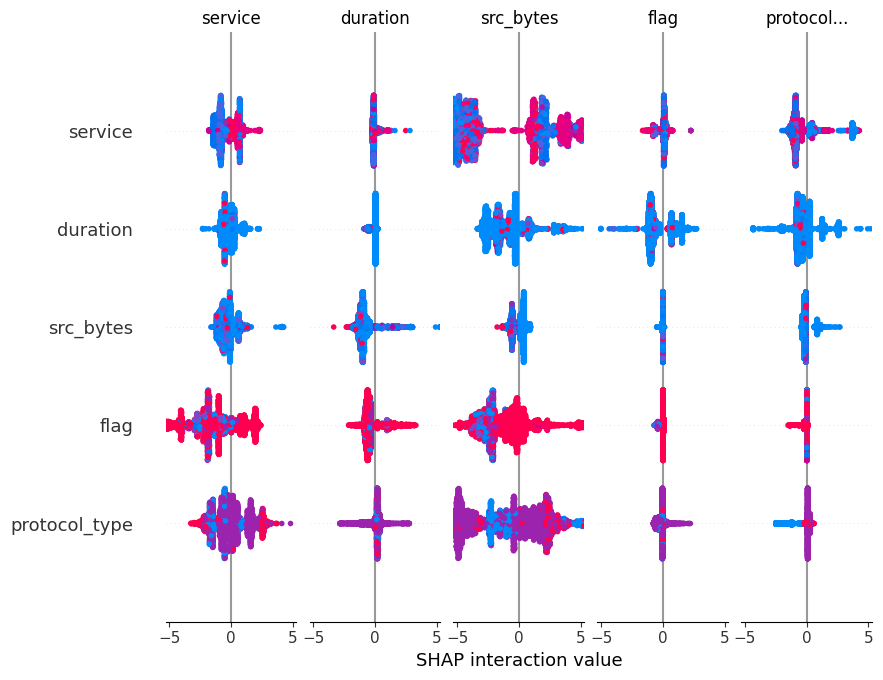

In [12]:
import shap

print("Calculating SHAP values from TRAINING set (X_res)...")
print("Note: SHAP dihitung dari training set agar tidak terjadi information leakage")

explainer = shap.TreeExplainer(model_xgb)

# FIX: gunakan X_res (training set), BUKAN X_test_scaled
# Gunakan subsample agar lebih cepat jika data besar
shap_sample_size = min(5000, X_res.shape[0])
np.random.seed(42)
shap_indices = np.random.choice(X_res.shape[0], shap_sample_size, replace=False)
X_shap = X_res[shap_indices]

shap_values = explainer.shap_values(X_shap)

feature_names = X_train.columns.tolist()

print(f"SHAP values shape: {np.array(shap_values).shape}")
print("Generating SHAP summary plot...")
shap.summary_plot(shap_values, X_shap, feature_names=feature_names,
                  class_names=label_encoder.classes_)

## 9. Feature Ranking dari SHAP

In [13]:
shap_array = np.array(shap_values)

# Handle shape: bisa (n_classes, n_samples, n_features) atau (n_samples, n_features, n_classes)
if shap_array.ndim == 3:
    if shap_array.shape[0] == len(label_encoder.classes_):
        # Shape: (n_classes, n_samples, n_features) -> average over classes and samples
        mean_abs_shap = np.mean(np.abs(shap_array), axis=(0, 1))
    else:
        # Shape: (n_samples, n_features, n_classes) -> average over samples and classes
        mean_abs_shap = np.mean(np.abs(shap_array), axis=(0, 2))
else:
    mean_abs_shap = np.mean(np.abs(shap_array), axis=0)

feature_importance = dict(zip(feature_names, mean_abs_shap))
sorted_feature_importance = sorted(feature_importance.items(),
                                    key=lambda x: x[1], reverse=True)

print("\nTop 15 Features by Mean |SHAP| (from training set):")
for i, (feat, imp) in enumerate(sorted_feature_importance[:15], 1):
    print(f"{i:2d}. {feat}: {imp:.4f}")


Top 15 Features by Mean |SHAP| (from training set):
 1. src_bytes: 1.1543
 2. dst_bytes: 0.7290
 3. count: 0.6558
 4. service: 0.5533
 5. dst_host_same_src_port_rate: 0.4440
 6. dst_host_srv_count: 0.4080
 7. logged_in: 0.3254
 8. dst_host_serror_rate: 0.3208
 9. dst_host_diff_srv_rate: 0.3055
10. dst_host_count: 0.2819
11. protocol_type: 0.2698
12. duration: 0.2652
13. dst_host_same_srv_rate: 0.2232
14. srv_count: 0.2068
15. dst_host_rerror_rate: 0.1981


## 10. Retrain dengan Top N Features
### Pipeline konsisten: SHAP (dari train) → filter fitur → scale → KMeans Undersample → SMOTE → train

In [15]:
results = {}
all_preds = {}

for top_n in [10, 20, 30]:
    print(f"\n{'='*55}")
    print(f" Processing Top {top_n} Features")
    print(f"{'='*55}")

    # 1. Pilih top N fitur dari SHAP (dihitung dari training set)
    top_features = [feat for feat, _ in sorted_feature_importance[:top_n]]
    print(f"  Features: {top_features}")

    # 2. Filter fitur dari data original (sebelum scaling)
    X_train_top = X_train[top_features]
    X_test_top  = X_test[top_features]

    # 3. Scaling — fit HANYA dari training set
    scaler_top = StandardScaler()
    X_train_top_scaled = scaler_top.fit_transform(X_train_top)
    X_test_top_scaled  = scaler_top.transform(X_test_top)

    # 4. KMeans Undersampling dari training set yang sudah difilter
    X_under_top, y_under_top = kmeans_undersample(
        X_train_top_scaled, y_train,
        sampling_strategy=sampling_strategy_under,
        cluster_strategy=cluster_strategy, # Added missing argument
        random_state=42
    )
    print(f"  After KMeans Undersampling: {Counter(y_under_top)}")

    # 5. BorderlineSMOTE
    smote_top = BorderlineSMOTE(
        kind='borderline-2',
        sampling_strategy={'r2l': 6000, 'u2r': 5000},
        k_neighbors=2, random_state=42
    )
    X_res_top, y_res_top = smote_top.fit_resample(X_under_top, y_under_top)
    print(f"  After SMOTE: {Counter(y_res_top)}")

    # 6. Encode target
    y_res_top_encoded = label_encoder.transform(y_res_top)

    # 7. Train XGBoost
    model_top = XGBClassifier(
        n_estimators=300, max_depth=8, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='mlogloss', random_state=42, n_jobs=-1
    )
    model_top.fit(X_res_top, y_res_top_encoded)

    # 8. Evaluasi di test set
    y_pred_top = model_top.predict(X_test_top_scaled)
    all_preds[top_n] = {
        'y_pred': y_pred_top,
        'model': model_top,
        'X_test_scaled': X_test_top_scaled,
        'X_res': X_res_top,
        'y_res_encoded': y_res_top_encoded,
        'top_features': top_features,
        'scaler': scaler_top,
    }

    report = classification_report(
        y_test_encoded, y_pred_top,
        target_names=label_encoder.classes_, output_dict=True
    )
    results[f'top_{top_n}'] = report

    print(f"\n  Classification Report (Top {top_n} Features):")
    print(classification_report(y_test_encoded, y_pred_top,
                                 target_names=label_encoder.classes_))


 Processing Top 10 Features
  Features: ['src_bytes', 'dst_bytes', 'count', 'service', 'dst_host_same_src_port_rate', 'dst_host_srv_count', 'logged_in', 'dst_host_serror_rate', 'dst_host_diff_srv_rate', 'dst_host_count']

Class : dos
Original samples : 45927
Target samples   : 10000
Clusters used    : 40

Class : normal
Original samples : 67343
Target samples   : 15000
Clusters used    : 40

Class : probe
Original samples : 11656
Target samples   : 8000
Clusters used    : 40
  After KMeans Undersampling: Counter({np.str_('normal'): 15000, np.str_('dos'): 10000, np.str_('probe'): 8000, np.str_('r2l'): 993, np.str_('u2r'): 52})
  After SMOTE: Counter({np.str_('normal'): 15000, np.str_('dos'): 10000, np.str_('probe'): 8000, np.str_('r2l'): 6000, np.str_('u2r'): 5000})

  Classification Report (Top 10 Features):
              precision    recall  f1-score   support

         dos       1.00      1.00      1.00      7562
      normal       0.94      0.99      0.97     11245
       probe    